In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target
X = df.drop("target",axis=1)
y = df["target"]


In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(data.target_names)
print(pd.Series(data.target).value_counts())

['malignant' 'benign']
1    357
0    212
Name: count, dtype: int64


In [5]:
cm = confusion_matrix(
    [0, 0, 1, 1],
    [0, 1, 1, 1],
    labels=[0, 1]
)

print(cm)

[[1 1]
 [0 2]]


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train,y_train) 
lr_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test,lr_pred,labels=[0,1])
print(cm)

[[41  1]
 [ 1 71]]


In [7]:
malignant_precision = precision_score(
    y_test,
    lr_pred,
    pos_label=0
)

malignant_recall = recall_score(
    y_test,
    lr_pred,
    pos_label=0
)

malignant_f1 = f1_score(
    y_test,
    lr_pred,
    pos_label=0
)

print("Malignant Precision:", malignant_precision)
print("Malignant Recall:", malignant_recall)
print("Malignant F1 Score:", malignant_f1)

Malignant Precision: 0.9761904761904762
Malignant Recall: 0.9761904761904762
Malignant F1 Score: 0.9761904761904762


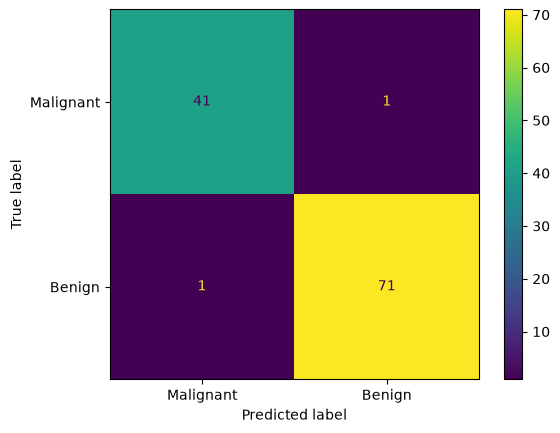

In [8]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.show()

In [9]:
probabilities = pipeline.predict_proba(X_test)

print(probabilities[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [10]:
malignant_proba = probabilities[:, 0]

print(malignant_proba[:10])

[9.99999941e-01 1.13351672e-05 9.93589175e-01 4.66491463e-01
 9.99999999e-01 7.83960163e-03 1.71746799e-05 9.99999436e-01
 9.99945684e-01 1.00000000e+00]


In [11]:
for threshold in [0.3, 0.5, 0.7]:

    custom_pred = np.where(
        malignant_proba >= threshold,
        0,
        1
    )

    cm = confusion_matrix(
        y_test,
        custom_pred,
        labels=[0, 1]
    )

    print(f"\nThreshold: {threshold}")
    print(cm)


Threshold: 0.3
[[41  1]
 [ 5 67]]

Threshold: 0.5
[[41  1]
 [ 1 71]]

Threshold: 0.7
[[40  2]
 [ 0 72]]


In [12]:
for threshold in [0.3, 0.5, 0.7]:

    custom_pred = np.where(
        malignant_proba >= threshold,
        0,
        1
    )

    precision = precision_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    recall = recall_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    f1 = f1_score(
        y_test,
        custom_pred,
        pos_label=0
    )

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)


Threshold: 0.3
Precision: 0.8913043478260869
Recall: 0.9761904761904762
F1 Score: 0.9318181818181818

Threshold: 0.5
Precision: 0.9761904761904762
Recall: 0.9761904761904762
F1 Score: 0.9761904761904762

Threshold: 0.7
Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(
    y_test,
    malignant_proba,
    pos_label=0
)

print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)

FPR: [0.         0.         0.         0.19444444 0.19444444 1.        ]
TPR: [0.         0.02380952 0.97619048 0.97619048 1.         1.        ]
Thresholds: [           inf 1.00000000e+00 6.48119737e-01 9.18002212e-02
 9.12718522e-02 4.20125791e-07]


In [15]:
y_test_malignant = (y_test == 0).astype(int)
roc_auc = roc_auc_score(y_test_malignant,malignant_proba)
print("ROC-AUC : ",roc_auc)

ROC-AUC :  0.9953703703703705


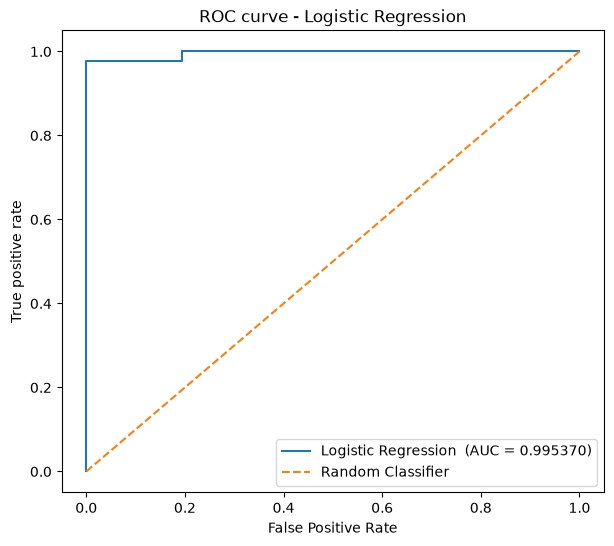

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,label=f"Logistic Regression  (AUC = {roc_auc:3f})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True positive rate")
plt.title("ROC curve - Logistic Regression")
plt.legend()
plt.show()


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [19]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=7))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            C=10,
            gamma=0.01,
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])
}

In [ ]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
KNN trained successfully
SVM trained successfully


c:\RAGForge\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
